# Домашнее задание 6. Графовые нейронные сети: проектирование и обучение простой GNN под прикладную задачу

В этом домашнем задании вы шаг за шагом:

- сформулируете прикладную задачу в графовой постановке;
- реализуете и обучите простую GCN-модель для классификации узлов;
- реализуете и обучите упрощенный вариант GraphSAGE и сравните его с GCN;
- добавите graph pooling и решите простую graph-level задачу на синтетических графах.

Все задачи — кодовые, с акцентом на понимание механики message passing, форм тензоров
и влияния архитектурных решений на качество моделей.


## Структура домашней работы

Домашнее задание состоит из 9 задач, разделенных на три уровня сложности:

- Простые задачи: 1–4.
- Средние задачи: 5–7.
- Сложные задачи: 8–9.

Задачи идут от базового представления графов к полноценным графовым нейронным сетям
для классификации узлов и графов.


## Цели занятия

После выполнения этого домашнего задания вы сможете:

1. Понять, как формулировать прикладную задачу в виде графовой модели с узлами, ребрами и признаками.
2. Освоить базовую реализацию GCN-слоя и message passing в матричной форме.
3. Научиться обучать и отлаживать простую GCN для классификации узлов на синтетических данных.
4. Проанализировать отличия GraphSAGE от GCN и влияние разных типов агрегации соседей.
5. Сравнить узловые и графовые постановки через добавление pooling-уровня и graph-level классификатора.
6. Интерпретировать полученные эмбеддинги узлов и графов и сделать практические выводы по выбору архитектуры.


## Теоретическая часть

### Граф как структура данных

Граф $G = (V, E)$ задается множеством узлов $V$ и ребер $E$. Узлам и ребрам часто сопоставляют
признаки: матрица признаков узлов $X \in \mathbb{R}^{N \times D}$, где $N$ — число узлов, $D$ — размерность признаков.
Структура графа кодируется матрицей смежности $A \in \mathbb{R}^{N \times N}$, где $A_{ij} = 1$, если есть ребро между
узлами $i$ и $j$, и $0$ иначе.

### Message passing и GNN

Идея графовых нейронных сетей: узлы итеративно обмениваются информацией с соседями. На каждом слое
обновление признаков узла можно записать в общем виде как
$$h_i^{(k+1)} = \mathrm{UPDATE}\Bigl(h_i^{(k)}, \mathrm{AGGREGATE}(\{h_j^{(k)} : j \in \mathit{N}(i)\})\Bigr),$$
где $\mathit{N}(i)$ — множество соседей узла $i$. В матричной форме это приводит к операциям вида
$H^{(k+1)} = \sigma(\tilde{A} H^{(k)} W^{(k)})$, где $\tilde{A}$ — нормализованная матрица смежности.

### GCN и GraphSAGE

- **GCN** использует фиксированную нормализующую матрицу $\tilde{A}$ и агрегирует соседей через
  умножение $\tilde{A} H$.
- **GraphSAGE** явно задает функцию агрегации (mean / sum / max) и обновляет признак узла как функцию
  от его собственного признака и агрегированных признаков соседей, что делает модель более гибкой
  и удобной для индуктивных сценариев.

В этом задании мы будем реализовывать простые варианты этих идей, не зависящие от конкретных фреймворков
для графов, используя только NumPy / PyTorch и NetworkX.

## Настройка окружения

In [1]:
# Импорт
import random

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используемое устройство:", DEVICE)


Используемое устройство: cuda


---

# ПРОСТЫЕ ЗАДАЧИ (1–4)

В этих задачах мы научимся представлять графы в виде матриц, задавать признаки узлов
и реализовывать один шаг агрегирования признаков соседей.


## Задача 1. Построение графа и матрицы смежности

### Постановка задачи

1. Сконструировать небольшой неориентированный граф с помощью NetworkX.
2. Получить его матрицу смежности в виде NumPy-массива.
3. Визуализировать граф и проверить согласованность между матрицей и рисунком.

### Теоретический минимум

- Матрица смежности полностью задает структуру графа.
- Степень узла равна сумме элементов соответствующей строки или столбца матрицы \(A\).


Форма матрицы смежности A: (8, 8)
[[0. 1. 1. 0. 0. 0. 0. 0.]
 [1. 0. 1. 1. 1. 0. 0. 0.]
 [1. 1. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 1. 0. 0. 0.]
 [0. 1. 1. 1. 0. 1. 1. 0.]
 [0. 0. 0. 0. 1. 0. 1. 1.]
 [0. 0. 0. 0. 1. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]]


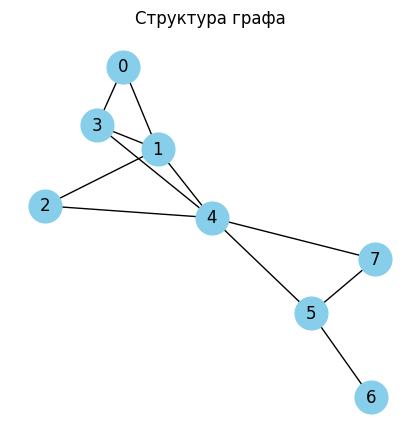

Степени узлов: [2. 4. 3. 2. 5. 3. 2. 1.]


In [2]:
# Задача 1. Построение графа и матрицы смежности

# DONE: Создайте граф G с помощью nx.Graph()
G = nx.Graph()
nodes = [0, 1, 3, 2, 4, 5, 7, 6]
G.add_nodes_from(nodes)

# DONE: Добавьте ребра. Используйте набор из 10–12 ребер на 6–8 узлов.
# Пример структуры: G.add_edges_from([(u1, v1), (u2, v2), ...])
G.add_edges_from([(0, 3), (0, 1), (3, 1), (3, 4), (1, 2), (1, 4),
                  (2, 4), (4, 7), (4, 5), (7, 5), (5, 6), ])

# DONE: Получите матрицу смежности A в виде NumPy-массива (dtype=np.float32)
A = nx.adjacency_matrix(G, dtype=np.float32).toarray()
print("Форма матрицы смежности A:", A.shape)
print(A)

# DONE: Визуализируйте граф (с метками узлов)
plt.figure(figsize=(4, 4))
pos = nx.spring_layout(G, seed=SEED)
nx.draw(G,
        pos=pos,
        with_labels=True,
        hide_ticks=True,
        node_color="skyblue",
        node_size=555,)
plt.title("Структура графа")
plt.show()

# TODO: Вычислите степени всех узлов через матрицу смежности
degrees = A.sum(axis=1)
print("Степени узлов:", degrees)

**Интерпретация:**
 1. Порядок, в котором указываются вершины, имеет значение для отрисовки
 1. Порядок, в котором указываются рёбра, значения для отрисовки не имеет
 1. Рёбра задаются кортежем (вершина1, вершина2). Для неориентированных графов порядок не имеет значения
 1. Пакет `networkx` имеет несколько методов для отображения графа. Некоторые из них:
    - **draw_random** - случайное размещение узлов
    - **draw_spring** - пружинная модель (force-directed)
    - **draw_spectral** - спектральная компоновка
    - **draw_shell** - многослойное круговое размещение
    - **draw_kamada_kawai** - энергетическая минимизация (аналог spring, но другой алгоритм)
    - **draw_planar** - плоская укладка без пересечений рёбер (если граф планарен)
    - **draw_geometric** - если узлы имеют координаты
 1. Метод `networkx.adjacency_matrix(G)` строит матрицу смежности вершин, которая отражает наличие связи между вершинами. У неориентированных графов матрица смежности симметрична
 1. **Степень всех узлов** показывает сколько связей существует у каждой вершины. _**В неориентированном графе**_ - просто число соседей. _**В ориентированном**_ - две степени: исходящая (сумма по строкам, сколько стрелок выходит) и входящая (сумма по столбцам, сколько входит).

 1. Для каждого грфа строится 3 матрицы:
   - $A$ - матрица смежности ($N \times N$, где $N$ - количество узлов)
   - $X$ - матрица признаков узлов ($D \times N$)
   - $E$ - матрица признаков ребер ($D \times E$)  
 Каждая из этих матриц фиксирует определенный аспект графа - структуру, свойства узлов и свойства связей соответственно.

## Задача 2. Признаки узлов и агрегирование соседей

### Постановка задачи

1. Задать простые числовые признаки для каждого узла (например, константа и степень).
2. Реализовать агрегирование признаков соседей через умножение \(A X\).
3. Проинтерпретировать полученные агрегированные признаки.

### Теоретический минимум

- Матрица признаков $(X \in \mathbb{R}^{N×D})$ хранит по строкам признаки узлов.
- Умножение \(A X\) дает для каждого узла сумму признаков его соседей.


In [ ]:
# Задача 2. Признаки узлов и агрегирование соседей

num_nodes = A.shape[0]

# TODO: Создайте матрицу признаков X формы (N, 2).
# Признак 1: константа (единица для каждого узла)
# Признак 2: нормированная степень узла (от 0 до 1)
degrees = ...
deg_norm = ...

X = ...  # форма: (N, 2), dtype=np.float32
print("Форма X:", X.shape)
print("Первые строки X:", X[:5])

# TODO: Выполните шаг агрегирования: AX = A @ X
AX = ...
print("Форма AX:", AX.shape)
print("Первые строки AX (агрегированные признаки соседей):", AX[:5])

# TODO: Проверьте вручную для нескольких узлов:
# выведите список соседей и соответствующий агрегированный признак
for i in range(num_nodes):
    neighbors = list(G.neighbors(i))
    # ваш код здесь

Форма X: (8, 2)
Первые строки X:  [[1.  0.4]
 [1.  0.8]
 [1.  0.6]
 [1.  0.4]
 [1.  1. ]]
Форма AX: (8, 2)
Первые строки AX (агрегированные признаки соседей):  [[2.        1.4000001]
 [4.        2.4      ]
 [3.        2.2      ]
 [2.        1.8      ]
 [5.        2.8000002]]
Узел 0: соседи [1, 3], агрегированный признак = [2.        1.4000001]
Узел 1: соседи [0, 2, 3, 4], агрегированный признак = [4.  2.4]
Узел 2: соседи [1, 4], агрегированный признак = [3.  2.2]
Узел 3: соседи [0, 1, 4], агрегированный признак = [2.  1.8]
Узел 4: соседи [1, 2, 3, 5, 7], агрегированный признак = [5.        2.8000002]
Узел 5: соседи [4, 6, 7], агрегированный признак = [3.  1.6]
Узел 6: соседи [5], агрегированный признак = [2.  1.6]
Узел 7: соседи [4, 5], агрегированный признак = [1.  0.6]


**Интерпретация:**

## Задача 3. Нормализованный шаг GCN

### Постановка задачи

1. Добавить к графу петли (self-loops).
2. Построить нормализованную матрицу смежности $\tilde{A} = D^{-1/2}(A + I)D^{-1/2}$.
3. Выполнить шаг $H = \tilde{A} X W$ и проверить формы тензоров.

### Теоретический минимум

- Добавление петель позволяет узлу сохранить собственные признаки при обновлении.
- Нормализация по степеням стабилизирует масштаб активаций.


In [ ]:
# Задача 3. Нормализованный шаг GCN

# TODO: Добавьте петли: A_hat = A + I
I = ...
A_hat = ...

# TODO: Вычислите диагональную матрицу степеней D_hat для A_hat
D_hat = ...

# TODO: Постройте D^{-1/2} как диагональную матрицу
# Подсказка: добавьте 1e-8, чтобы избежать деления на ноль
D_inv_sqrt = ...

# TODO: Нормализуйте: A_norm = D_inv_sqrt @ A_hat @ D_inv_sqrt
A_norm = ...
print("Форма A_norm:", A_norm.shape)

# TODO: Задайте случайную матрицу весов W формы (in_dim, out_dim)
in_dim = X.shape[1]
out_dim = 4
W = ...  # np.random.randn, масштаб ~0.1
print("Форма W:", W.shape)

# TODO: Выполните один шаг GCN: H = A_norm @ X @ W
H = ...
print("Форма H:", H.shape)
print("Первые строки H:", H[:5])


Форма A_norm: (8, 8)
Форма W: (2, 4)
Форма H: (8, 4)
Первые строки H:  [[ 0.0317068  -0.02418363  0.13803904  0.17343509]
 [ 0.03976043 -0.03151977  0.18061535  0.22341071]
 [ 0.03281839 -0.02854525  0.16500175  0.1969531 ]
 [ 0.02761216 -0.0249145   0.14447768  0.17016342]
 [ 0.04356749 -0.03446337  0.1974407   0.24443296]]


**Интерпретация:**


## Задача 4. Простая узловая задача на синтетическом графе

### Постановка задачи

1. Сгенерировать синтетический граф с двумя группами узлов (два класса).
2. Задать базовые признаки узлов.
3. Реализовать один шаг GCN (без обучения) и визуализировать узлы в 2D-пространстве признаков.

### Теоретический минимум

- Даже один шаг message passing может сделать узлы одного класса более похожими друг на друга
  в скрытом пространстве.


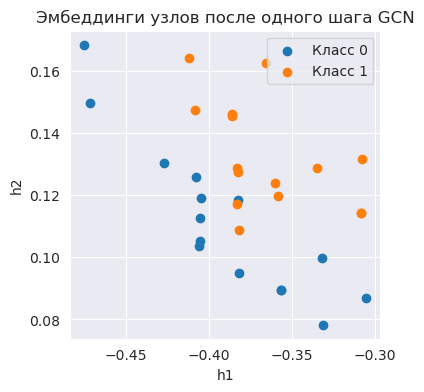

In [ ]:
# Задача 4. Узловая задача и визуализация эмбеддингов

# TODO: Сгенерируйте граф с двумя кластерами по 15 узлов
# nx.planted_partition_graph(l=..., k=..., p_in=..., p_out=..., seed=SEED)
G2 = ...
A2 = nx.to_numpy_array(G2, dtype=np.float32)
num_nodes2 = A2.shape[0]

# TODO: Задайте метки узлов: первые 15 — класс 0, вторые 15 — класс 1
labels2 = ...

# TODO: Постройте матрицу признаков X2 аналогично Задаче 2
deg2 = ...
deg2_norm = ...
X2 = ...  # форма (N, 2)

# TODO: Выполните нормализованный шаг GCN (аналогично Задаче 3)
# A2_norm = ...

# TODO: Задайте случайную матрицу весов W2 формы (2, 2)
W2 = ...

# TODO: Вычислите H2 = A2_norm @ X2 @ W2
H2 = ...

# TODO: Визуализируйте H2 как scatter plot:
# ось X — H2[:, 0], ось Y — H2[:, 1], цвет — метка класса
plt.figure(figsize=(4, 4))
# ваш код здесь
plt.legend()
plt.xlabel("h1")
plt.ylabel("h2")
plt.title("Эмбеддинги узлов после одного шага GCN")
plt.grid(True)
plt.show()

**Интерпретация:**


---

# СРЕДНИЕ ЗАДАЧИ (5–7)

Теперь будем обучать GCN и GraphSAGE на узловой задаче и сравнивать их результаты.


## Задача 5. Обучение простого GCN для классификации узлов

### Постановка задачи

1. Реализовать один GCN-слой в PyTorch с использованием нормализованной матрицы смежности.
2. Собрать из него простую модель с двумя слоями для классификации узлов на синтетическом графе.
3. Обучить модель и оценить качество на обучающем и тестовом подмножествах узлов.

### Теоретический минимум

- GCN-слой: $H^{(l+1)} = \sigma(\tilde{A} H^{(l)} W^{(l)})$.
- В узловой задаче разделение на train / test обычно делается по узлам, а не по графам.


In [ ]:
# Задача 5. Реализация и обучение GCN

# --- Шаг 1. Подготовка данных ---
def numpy_to_torch(x):
    return torch.from_numpy(x).float()

# TODO: Конвертируйте A2_norm, X2, labels2 в тензоры и перенесите на DEVICE
A2_norm_t = ...
X2_t = ...
labels2_t = ...

# --- Шаг 2. Разбиение узлов ---
# TODO: Перемешайте индексы и разделите на train (70%) и test (30%)
idx = np.arange(num_nodes2)
# ваш код здесь
idx_train = ...
idx_test = ...

# --- Шаг 3 & 4. Архитектура модели ---
class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        # TODO: инициализируйте линейный слой
        ...

    def forward(self, x, A_norm):
        # TODO: умножьте A_norm @ x, затем примените линейный слой
        ...

class GCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        # TODO: два слоя GCNLayer
        ...

    def forward(self, x, A_norm):
        # TODO: первый слой → ReLU → второй слой
        ...

# --- Шаг 5. Оптимизатор и функция потерь ---
model_gcn = GCN(in_dim=2, hidden_dim=16, out_dim=2).to(DEVICE)
# TODO: настройте Adam (lr=0.01, weight_decay=5e-4) и CrossEntropyLoss
optimizer = ...
criterion = ...

# --- Шаг 6. Цикл обучения ---
EPOCHS = 200

for epoch in range(EPOCHS):
    model_gcn.train()
    optimizer.zero_grad()
    # TODO: forward pass
    logits = ...
    # TODO: потеря только по обучающим узлам
    loss = ...
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 40 == 0:
        model_gcn.eval()
        with torch.no_grad():
            # TODO: вычислите train_acc и test_acc
            pred = ...
            train_acc = ...
            test_acc = ...
        print(f"Эпоха {epoch+1:3d}, loss = {loss.item():.4f}, train_acc = {train_acc:.2f}, test_acc = {test_acc:.2f}")

Эпоха  40, loss = 0.5878, train_acc = 0.62, test_acc = 0.56
Эпоха  80, loss = 0.3611, train_acc = 0.90, test_acc = 1.00
Эпоха 120, loss = 0.2128, train_acc = 0.90, test_acc = 1.00
Эпоха 160, loss = 0.1609, train_acc = 0.90, test_acc = 1.00
Эпоха 200, loss = 0.1359, train_acc = 0.90, test_acc = 1.00


**Интерпретация:**

## Задача 6. Реализация и обучение упрощенного GraphSAGE

### Постановка задачи

1. Реализовать слой GraphSAGE с mean-агрегацией соседей.
2. Обучить модель GraphSAGE на той же задаче классификации узлов и с тем же разбиением.
3. Сравнить результаты с GCN по точности и стабильности обучения.

### Теоретический минимум

- GraphSAGE агрегирует соседей по формуле
  $h_i^{(l+1)} = \sigma\bigl(W_1 h_i^{(l)} + W_2 \cdot \mathrm{mean}_{j \in \mathit{N}(i)} h_j^{(l)}\bigr)$.
- В отличие от GCN, здесь агрегация задается явно, что удобно для индуктивных задач.

In [ ]:
# Задача 6. Реализация и обучение GraphSAGE

# --- Шаг 1. Списки соседей ---
# TODO: Создайте список neighbors_list, где neighbors_list[i] — список соседей узла i
neighbors_list = ...

# --- Шаги 2–4. Архитектура ---
class GraphSAGELayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        # TODO: два линейных слоя: для собственного признака и для агрегата
        ...

    def forward(self, x):
        # x: (N, D)
        N = x.shape[0]
        neigh_agg = torch.zeros_like(x)
        # TODO: для каждого узла i усредните признаки его соседей из neighbors_list[i]
        for i in range(N):
            ...
        # TODO: верните сумму двух линейных преобразований: self и neigh
        out = ...
        return out

class GraphSAGE(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        # TODO: два слоя GraphSAGELayer
        ...

    def forward(self, x):
        # TODO: первый слой → ReLU → второй слой
        ...

# --- Шаг 5. Обучение ---
model_sage = GraphSAGE(in_dim=2, hidden_dim=16, out_dim=2).to(DEVICE)
optimizer_sage = torch.optim.Adam(model_sage.parameters(), lr=0.01, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

EPOCHS_SAGE = 200

for epoch in range(EPOCHS_SAGE):
    model_sage.train()
    optimizer_sage.zero_grad()
    # TODO: forward pass и loss по idx_train
    logits_sage = ...
    loss_sage = ...
    loss_sage.backward()
    optimizer_sage.step()

    if (epoch + 1) % 40 == 0:
        model_sage.eval()
        with torch.no_grad():
            # TODO: вычислите train_acc и test_acc для SAGE
            pred_sage = ...
            train_acc_sage = ...
            test_acc_sage = ...
        print(f"[SAGE] Эпоха {epoch+1:3d}, loss = {loss_sage.item():.4f}, train_acc = {train_acc_sage:.2f}, test_acc = {test_acc_sage:.2f}")

[SAGE] Эпоха  40, loss = 0.6569, train_acc = 0.57, test_acc = 0.33
[SAGE] Эпоха  80, loss = 0.3600, train_acc = 0.90, test_acc = 0.89
[SAGE] Эпоха 120, loss = 0.1904, train_acc = 0.90, test_acc = 1.00
[SAGE] Эпоха 160, loss = 0.1356, train_acc = 0.95, test_acc = 1.00
[SAGE] Эпоха 200, loss = 0.1109, train_acc = 0.95, test_acc = 1.00


**Интерпретация:**


## Задача 7. Сравнение эмбеддингов GCN и GraphSAGE

### Постановка задачи

1. Получить скрытые представления узлов после первого слоя GCN и GraphSAGE.
2. Визуализировать их в двумерном пространстве (например, взять первые две координаты).
3. Проанализировать, какая модель лучше разделяет классы узлов.

### Теоретический минимум

- Эмбеддинги узлов отражают то, как модель видит структуру графа и признаки.
- В хорошей модели эмбеддинги узлов одного класса образуют кластеры.


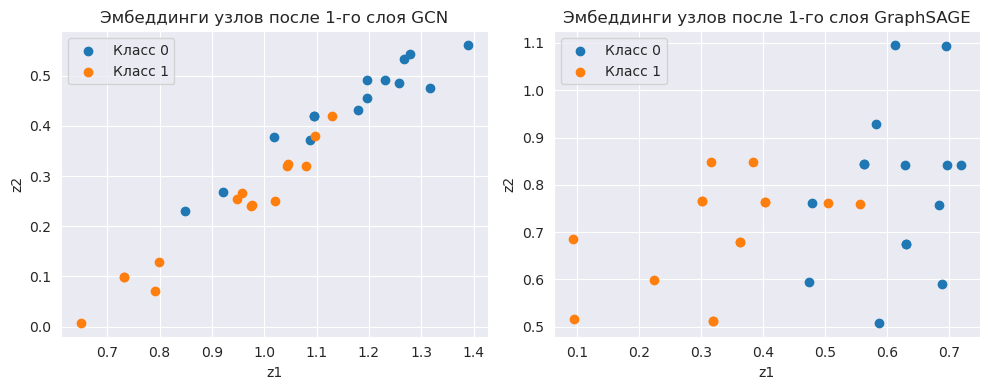

In [ ]:
# Задача 7. Визуализация и сравнение эмбеддингов

model_gcn.eval()
model_sage.eval()

with torch.no_grad():
    # TODO: получите эмбеддинги после первого слоя GCN (с ReLU)
    # Обратитесь напрямую к model_gcn.gcn1 с нужными аргументами
    h_gcn1 = ...
    h_gcn1 = F.relu(h_gcn1)

    # TODO: получите эмбеддинги после первого слоя GraphSAGE (с ReLU)
    h_sage1 = ...
    h_sage1 = F.relu(h_sage1)

# TODO: Переведите тензоры в numpy
h_gcn_np = ...
h_sage_np = ...

# TODO: Постройте два scatter plot рядом (1 строка, 2 колонки):
# Левый — GCN, правый — GraphSAGE
# Для каждого класса (0 и 1) отдельный цвет
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
# ваш код здесь — GCN
plt.title("Эмбеддинги узлов после 1-го слоя GCN")
plt.xlabel("z1"); plt.ylabel("z2")
plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
# ваш код здесь — GraphSAGE
plt.title("Эмбеддинги узлов после 1-го слоя GraphSAGE")
plt.xlabel("z1"); plt.ylabel("z2")
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()

**Интерпретация:**


---

# СЛОЖНЫЕ ЗАДАЧИ (8–9)

Теперь перейдем к graph-level задачам с использованием pooling и сделаем
итоговое сравнение моделей.


## Задача 8. Graph-level классификация с pooling

### Постановка задачи

1. Сгенерировать набор синтетических графов двух разных классов (например, более разреженные и более плотные).
2. Для каждого графа задать признаки узлов и применить один шаг message passing (GCN или GraphSAGE).
3. Выполнить global mean pooling для получения эмбеддинга графа и обучить простой MLP-классификатор.

### Теоретический минимум

- В graph-level задачах агрегация по узлам (readout / pooling) превращает переменное число узлов
  в фиксированный вектор признаков графа.


In [ ]:
# Задача 8. Реализация graph-level классификации
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# --- A. Генерация данных ---

num_graphs_per_class = 40
num_nodes_min, num_nodes_max = 10, 15

graphs = []
labels_graph = []

for cls in [0, 1]:
    for _ in range(num_graphs_per_class):
        n = np.random.randint(num_nodes_min, num_nodes_max + 1)
        # TODO: Выберите вероятность ребра p в зависимости от cls (0 → разреженный, 1 → плотный)
        p = ...
        # TODO: Сгенерируйте граф Эрдёша–Реньи
        Gg = ...
        # TODO: Если граф не связный, возьмите наибольшую компоненту связности
        if not nx.is_connected(Gg):
            Gg = ...
        graphs.append(Gg)
        labels_graph.append(cls)

labels_graph = np.array(labels_graph, dtype=np.int64)

# --- B. Graph embedding через GCN + mean pooling ---

def graph_embedding_gcn_like(Gg):
    """
    Вычисляет эмбеддинг графа через один нормализованный шаг GCN и mean pooling.

    Возвращает:
        h_graph: np.ndarray формы (out_dim,)
    """
    A = nx.to_numpy_array(Gg, dtype=np.float32)
    n = A.shape[0]

    # TODO: Постройте матрицу признаков X: константа + нормированная степень (форма n x 2)
    X = ...

    # TODO: Нормализованная матрица смежности (аналогично Задаче 3)
    A_norm = ...

    # TODO: Случайная матрица весов W формы (2, 4), масштаб ~0.1
    W = ...

    # TODO: H = ReLU(A_norm @ X @ W)
    H = ...

    # TODO: Mean pooling: усредните H по всем узлам → вектор формы (4,)
    h_graph = ...
    return h_graph

# Применяем функцию ко всем графам
X_graph = np.stack([graph_embedding_gcn_like(Gg) for Gg in graphs], axis=0)
print("Форма X_graph:", X_graph.shape)

# --- C. Обучение классификатора ---

# TODO: Разбейте X_graph и labels_graph на train/test (test_size=0.3, stratify=labels_graph)
X_train_g, X_test_g, y_train_g, y_test_g = ...

class GraphMLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        # TODO: nn.Sequential с двумя Linear слоями и ReLU между ними
        self.net = ...

    def forward(self, x):
        return self.net(x)

model_graph = GraphMLP(in_dim=4, hidden_dim=16, out_dim=2).to(DEVICE)
optimizer_graph = torch.optim.Adam(model_graph.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

# TODO: Конвертируйте X_train_g, X_test_g, y_train_g, y_test_g в тензоры PyTorch
X_train_t = ...
X_test_t = ...
y_train_t = ...
y_test_t = ...

EPOCHS_GRAPH = 200

for epoch in range(EPOCHS_GRAPH):
    model_graph.train()
    optimizer_graph.zero_grad()
    # TODO: forward pass и loss
    logits_g = ...
    loss_g = ...
    loss_g.backward()
    optimizer_graph.step()

    if (epoch + 1) % 50 == 0:
        model_graph.eval()
        with torch.no_grad():
            # TODO: вычислите train_acc и test_acc
            ...
        print(f"Эпоха {epoch+1:3d}, loss = {loss_g.item():.4f}, train_acc = {train_acc_g:.2f}, test_acc = {test_acc_g:.2f}")

Эпоха  50, loss = 0.6665, train_acc = 0.61, test_acc = 0.50
Эпоха 100, loss = 0.6229, train_acc = 0.66, test_acc = 0.50
Эпоха 150, loss = 0.6135, train_acc = 0.68, test_acc = 0.46
Эпоха 200, loss = 0.6088, train_acc = 0.68, test_acc = 0.46


**Интерпретация:**

## Задача 9. Итоговое сравнение GCN, GraphSAGE и graph-level модели

### Постановка задачи

1. Сравнить точность GCN и GraphSAGE на узловой задаче.
2. Сравнить точность graph-level модели на задачах классификации графов.
3. Сформулировать выводы: какая архитектура лучше подходит для какой постановки,
   как влияют глубина и тип агрегации.

### Теоретический минимум

- Разные архитектуры GNN по-разному используют структуру графа и признаки.
- Выбор модели зависит от типа задачи (узловая vs графовая) и требований
  к индуктивности и масштабируемости.


In [ ]:
# Задача 9. Сводка метрик

# --- Узловая задача ---
model_gcn.eval()
model_sage.eval()

with torch.no_grad():
    # TODO: вычислите финальные train_acc и test_acc для GCN
    logits_gcn = ...
    pred_gcn = ...
    train_acc_gcn = ...
    test_acc_gcn = ...

    # TODO: вычислите финальные train_acc и test_acc для GraphSAGE
    logits_sage = ...
    pred_sage = ...
    train_acc_sage = ...
    test_acc_sage = ...

# --- Graph-level задача ---
model_graph.eval()
with torch.no_grad():
    # TODO: вычислите финальные train_acc и test_acc для graph-level модели
    ...
    train_acc_graph = ...
    test_acc_graph = ...

# --- Сводная таблица ---
print("=" * 60)
print(f"{'Модель':<25} {'train_acc':>10} {'test_acc':>10}")
print("=" * 60)
print(f"{'GCN (узловая)':<25} {train_acc_gcn:>10.3f} {test_acc_gcn:>10.3f}")
print(f"{'GraphSAGE (узловая)':<25} {train_acc_sage:>10.3f} {test_acc_sage:>10.3f}")
print(f"{'Graph MLP + pooling':<25} {train_acc_graph:>10.3f} {test_acc_graph:>10.3f}")
print("=" * 60)



GCN:    train_acc = 0.905, test_acc = 1.000
GraphSAGE: train_acc = 0.952, test_acc = 1.000
Graph-level MLP + pooling: train_acc = 0.679, test_acc = 0.458


**Интерпретация:**


---

## Интерпретация результатов

В этом задании:

- мы увидели, как граф задается через матрицу смежности и матрицу признаков,
  и как базовые линейные операции реализуют message passing;
- реализовали нормализованный шаг GCN и проверили согласованность размерностей;
- обучили простую GCN-модель для классификации узлов и убедились, что структура графа
  помогает улучшить качество;
- реализовали упрощенный GraphSAGE и сравнили его поведение с GCN по качеству и
  эмбеддингам узлов;
- построили простую graph-level модель на основе одного шага message passing и pooling
  и показали, что она умеет различать классы графов.

Мы также увидели, что выбор архитектуры (GCN vs GraphSAGE) и типа pooling влияет
на разделимость классов и поведение модели на узловых и графовых задачах.


## Выводы

1. Графовые нейронные сети опираются на простые матричные операции (умножение на матрицу смежности
   и линейные преобразования), которые реализуют шаги message passing.
2. GCN использует фиксированную нормализованную матрицу \(	ilde{A}\), что делает слой компактным и
   удобным для трандуктивных задач.
3. GraphSAGE задает агрегацию соседей явно и хорошо подходит для индуктивных сценариев, где
   граф может меняться или расширяться.
4. Для graph-level задач критично использовать pooling, который агрегирует признаки узлов
   в фиксированный вектор представления графа.
5. Практический выбор архитектуры зависит от постановки: для узловых задач с фиксированным графом
   удобно использовать GCN, для более гибких сценариев и больших графов — варианты GraphSAGE,
   а для задач на графах — комбинации message passing и pooling.
